# Metagenomic assembly tutorial



In [2]:
from google.colab import drive
import os,glob
drive.mount('/content/drive')
py_env='/content/drive/MyDrive/workshop_June2023/assembly_based_metagenomic_analysis/python_env'
root_dir = "/content/drive/MyDrive/workshop_June2023"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup the environment





In [ ]:
# conda environment
import os,sys
sys.path.append(py_env)
import condacolab
condacolab.install()

# Setup tools for metagenomic assembly # 3 min
!conda install -c bioconda megahit

In [3]:
! which megahit

/usr/local/bin/megahit


In [ ]:
# pre installed
# ! pip install matplotlib --target={py_env}

In [4]:
# mgx reads folder
import os
mgx_reads_dir = os.path.join(root_dir,"mgx_reads")
! ls -lh {mgx_reads_dir}
contig_demo_dir = os.path.join(root_dir,"assembly_based_metagenomic_analysis","contig_demo")
contig_demo_tmp_dir = os.path.join(root_dir,"assembly_based_metagenomic_analysis","tmp")
! mkdir -p {contig_demo_dir}
! mkdir -p {contig_demo_tmp_dir}

sample_id="PSMB4MBK"
p1 = os.path.join(mgx_reads_dir,sample_id+"_R1.fastq.gz")
p2 = os.path.join(mgx_reads_dir,sample_id+"_R2.fastq.gz")

total 780M
-rw------- 1 root root  15K May  3 04:55 PSMB4MBK.log
-rw------- 1 root root 389M May  3 04:55 PSMB4MBK_R1.fastq.gz
-rw------- 1 root root 391M May  3 04:55 PSMB4MBK_R2.fastq.gz
-rw------- 1 root root 482K Jun 12 14:25 PSMB4MBK_subset_R1.fastq.gz
-rw------- 1 root root 478K Jun 12 14:27 PSMB4MBK_subset_R2.fastq.gz


In [1]:
! megahit --help

MEGAHIT v1.2.9

contact: Dinghua Li <voutcn@gmail.com>

Usage:
  megahit [options] {-1 <pe1> -2 <pe2> | --12 <pe12> | -r <se>} [-o <out_dir>]

  Input options that can be specified for multiple times (supporting plain text and gz/bz2 extensions)
    -1                       <pe1>          comma-separated list of fasta/q paired-end #1 files, paired with files in <pe2>
    -2                       <pe2>          comma-separated list of fasta/q paired-end #2 files, paired with files in <pe1>
    --12                     <pe12>         comma-separated list of interleaved fasta/q paired-end files
    -r/--read                <se>           comma-separated list of fasta/q single-end files

Optional Arguments:
  Basic assembly options:
    --min-count              <int>          minimum multiplicity for filtering (k_min+1)-mers [2]
    --k-list                 <int,int,..>   comma-separated list of kmer size
                                            all must be odd, in the range 15-255, inc

# Run megahit


In [5]:
# ! rm -rf {contig_demo_dir}
# ! megahit --tmp-dir {contig_demo_tmp_dir} -1 {p1} -2 {p2}  -t 4 -m 0.9 -o {contig_demo_dir} --out-prefix {sample_id};
# The pre-calculated file is here:
contig_dir = os.path.join(root_dir,"assembly_based_metagenomic_analysis","contigs")
! ls {contig_dir}/{sample_id}*

/content/drive/MyDrive/workshop_June2023/assembly_based_metagenomic_analysis/contigs/PSMB4MBK_contigs.fna


## Check the output file

In [6]:
! head {contig_dir}/{sample_id}_contigs.fna

>k105_1 flag=1 multi=4.0000 len=340
AGCAATACGCTTGGTGCCATATCTACACGGTCGGCAATTTCTTTCATCTTTACGCCATTGTTGCGCAGGTATTCTATTCTTTTGTAAATGTCGGTCAGTTCATCCATGATTCTTGAGGTTGCAAATTGAATTTCGTTGCAAAGGAATGACTAATGTATTATGATTTTGTTGCATGAATATTACATTAATATTTCACTCTGTCCGAAAAGAAAAATATACGATATGATTCATTGAAATTCATTTTTTCACTCGTCCCGGTGTCCTACATTTGCACCGGAAACAAAAAAATGACGCTATATGAATTTCAAAGAAAAACTGTCGCCTTCGGCTCAAAAAAAAC
>k105_2 flag=1 multi=11.0000 len=2417
ATTTTTTTTATTTTCATAATTAGTATTTTTAGAATGATAAGTTTAATCCAAAGGTGAACAATCGTTGCATAGGATGGCTGGTTCCTAATATTTCAGGGTCATAATTCTTTGAAAGCTTGGTAAACTCAAAAATATTATCGCCTGTAAGATATAATCTTACTCGTTCTAATTTAGCTTTCATCGTAAACTTTTTAGGTAATGTATAACCGATAGTGATATTCTTTATGCGGAGATAGGCTGCATTTTGCAAATATCGCGTCTGATTAATTGCCAAGTCCTTTCCACCTTCTGCAATATAAGATTTTAATCTTGGGAAATAAGCATCAGTATTTTCTGGAGTCCAATGGTCTAAATTATTTTCAAGCACATTTCCCCAAGGAGCTCTATATATGCCAAAGAAATAATGACTTTCCGGATACCAATCCTTTTTGCCTACTCCTTGCAACAGAACACGGAAATCAAGTCCATTCCATTCGGCTGTAAAATCAGCACCATAATTATATCGTGACGCATTGTTACCAATTACTTTATAGTCACCAGGATCATTTACAGTCCAAGAACCATTGTTAATCTTTCCATTGTTAT

### Reminder: fasta format:

*   Commonly used to save sequences [DNA/RNA/Protein]
*   Each sequence is recorded on two lines


> 1.   A header line that starts with **>**, which is the identifier for the sequence
> 2.   A sequence line: recording the sequence associated with the header above (e.g. nucleotides for DNA reads)









In [7]:
# show the first few headers
! grep ">" {contig_dir}/{sample_id}_contigs.fna | head

>k105_1 flag=1 multi=4.0000 len=340
>k105_2 flag=1 multi=11.0000 len=2417
>k105_3 flag=1 multi=7.0000 len=436
>k105_4 flag=1 multi=8.0000 len=5510
>k105_5 flag=1 multi=8.0000 len=333
>k105_6 flag=1 multi=9.0000 len=597
>k105_7 flag=1 multi=9.0000 len=4108
>k105_8 flag=1 multi=5.0000 len=365
>k105_9 flag=1 multi=3.0000 len=360
>k105_10 flag=1 multi=4.3822 len=487


## Task 1 (3 min):
How many contigs are assembled?

Hint:


*   **grep** the headers starting with **">"**, remember to add quotation marks to avoid overwrite
*   count with the **wc** commend





In [ ]:
! grep ">" {contig_dir}/{sample_id}_contigs.fna | wc -l

57568


## Collect the length of each contigs

In [8]:
def get_length(fp):
  # a list to save the length of each contig
  length_lst = []
  with open(fp,"r") as f:
    # iterate throught each line
    for line in f:
      # collect the lengths from header lines [started with ">"]
          # >k105_1 flag=1 multi=4.0000 len=340\n
      if ">" in line:
        # add the length into the list
        # .strip(): remove the newline character [\n]
          # >k105_1 flag=1 multi=4.0000 len=340
        # .split(): split the string by a pattern
          # len=340
          # 340
        length_lst.append(int(line.strip().split(" ")[-1].split("=")[1]))
  return length_lst

contig_fp = os.path.join(contig_dir,sample_id+"_contigs.fna")
length_lst = get_length(contig_fp)
length_lst[:10]
#

[340, 2417, 436, 5510, 333, 597, 4108, 365, 360, 487]

## Overview of the length distribution of contigs

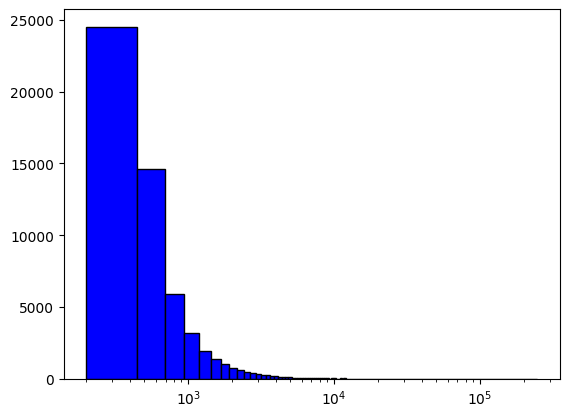

In [9]:
import matplotlib.pyplot as plt
plt.hist(length_lst, color = 'blue', edgecolor = 'black', bins = 1000)
plt.xscale("log")
plt.show()

## Evaluation of the assembly result

Notice that most of the contigs are very short (<1000 bp), which indicates that our assembly is very fragmented

**What is a good sequence assembly?**

Let's start by asking the opposite question: what is a bad assembly?

*   Too fragmented
*   Too long: reads connected directly by head to tail
*   Ideal assembly: A concise set of continuous contigs that explain as much of the input reads as possible.

Commonly used evaluation metrics: N50 and L50


### Calculate the N50


*   Input: a list of contig lengths
*   Output: the N50 values of the assembly
*   Workflow:
> 1. calculate the total length of the contigs
> 2. sort the contig lengths from long to short
> 3. sum up the contig lengths from long to short, until you reach 50% of the total length of all contigs
> 4. return the length of the last visited contig



In [ ]:
# a function to calculate the total length of the contigs
def calculate_total_length(length_lst):
  total_length = 0
  for L in length_lst:
    total_length = total_length+L
  return total_length

total_length = calculate_total_length(length_lst)
print("the total length is:",total_length)

# sort the length from short to long
print("before sorting:",length_lst[:10])
length_lst.sort(reverse=True)
print("after sorting:",length_lst[:10])

cur_L = length_lst[0]
cur_sum = cur_L
for next_L in length_lst[1:]:
  # when the length sum of visited contigs reach the half of the total length, current L will the our N50
  if cur_sum>0.5*total_length:
    break
  cur_sum = cur_sum+next_L
  cur_L = next_L
print("N50 is:",cur_L)
#

the total length is: 58289010
before sorting: [340, 2417, 436, 5510, 333, 597, 4108, 365, 360, 487]
after sorting: [245961, 231815, 221821, 173467, 155963, 133906, 127401, 108266, 103391, 101513]
N50 is: 1640


### Task: Calculate the L50 [5 minutes]

The L50 is defined as the smallest number of contigs whose length sum up to 50% of the total size of all contigs

*   Input: a list of contig lengths
*   Output: :50 values of the assembly
*   Workflow:
> 1. calculate the total length of all contigs together
> 2. sort the contig lengths from long to short
> 3. sum up the contig lengths from long to short, until you reach 50% of the total length of all contigs
> 4. return the total number of visited contigs



### The answer

In [ ]:
# a function to calculate the total length of the contigs
def calculate_total_length(length_lst):
  total_length = 0
  for L in length_lst:
    total_length = total_length+L
  return total_length

total_length = calculate_total_length(length_lst)
print("the total length is:",total_length)

# sort the length from short to long
print("before sorting:",length_lst[:10])
length_lst.sort(reverse=True)
print("after sorting:",length_lst[:10])

cur_L = length_lst[0]
cur_idx = 1
cur_sum = cur_L
for next_L in length_lst[1:]:
  # when the length sum of visited contigs reach the half of the total length, current L will the our N50
  if cur_sum>0.5*total_length:
    break
  cur_sum = cur_sum+next_L
  cur_L = next_L
  cur_idx = cur_idx+1
print("L50 is:",cur_idx)
#

the total length is: 58289010
before sorting: [245961, 231815, 221821, 173467, 155963, 133906, 127401, 108266, 103391, 101513]
after sorting: [245961, 231815, 221821, 173467, 155963, 133906, 127401, 108266, 103391, 101513]
L50 is: 6258


### Your solution

In [ ]:
# your solution

## Discussion:

What is a good assembly?

*   N50: the larger the better
*   L50: the smaller the better

